<a href="https://colab.research.google.com/github/1Aadi0/GW-ANALYSIS/blob/main/GW150914_Frequency_Evolution_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")



In [ ]:
# ! pip uninstall -y numpy
# !pip install numpy==1.26.4
! pip install -q -U 'scipy==1.12.0' 'lalsuite==7.25' 'PyCBC==2.4.1'

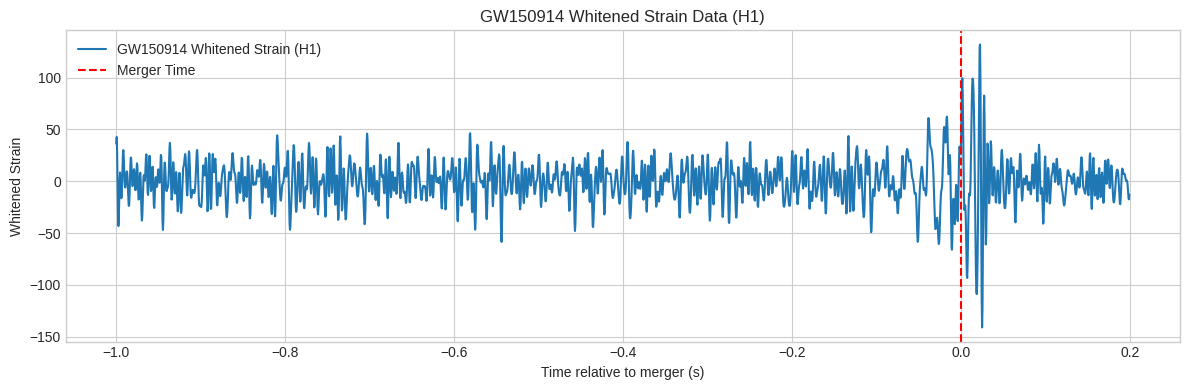

Slope from linregress (f^-8/3 vs time_to_merger): 2.812e-08
Estimated chirp mass: 0.00 M_sun (GW150914 expected: ~28-31 M_sun)


<ipython-input-53-bc4cd29b1d8c>:113: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


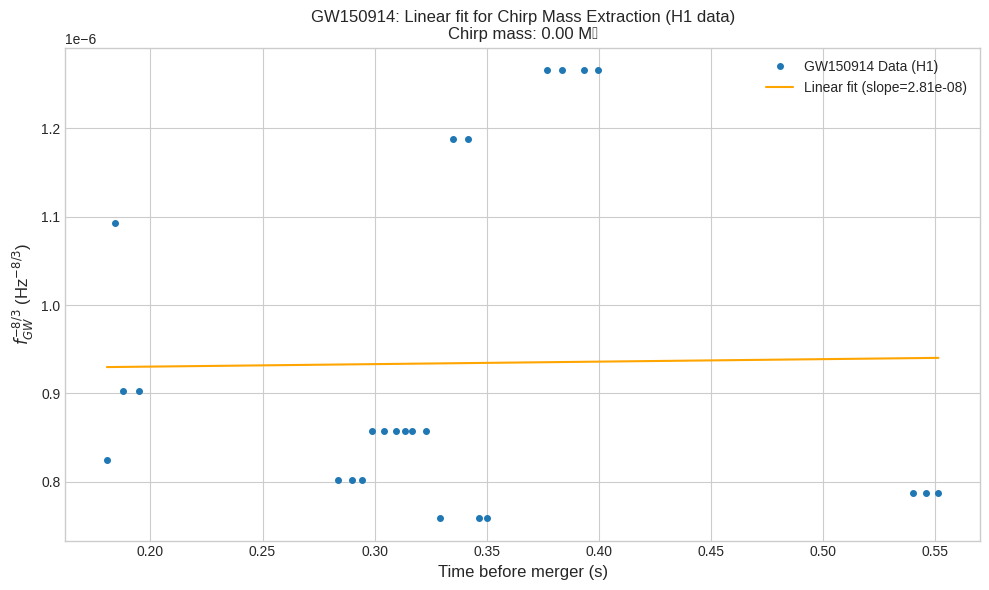

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc.catalog import Merger
from pycbc.filter import resample_to_delta_t, highpass
from pycbc.psd import interpolate, inverse_spectrum_truncation
from scipy.stats import linregress
from scipy.constants import G, c, pi
from scipy.ndimage import median_filter

# Constants
M_SOLAR = 1.98847e30

# 1. Data loading and conditioning for GW150914
merger = Merger("GW150914")
event_time = merger.time
strain = merger.strain('H1')
strain = highpass(strain, 15.0)
strain = resample_to_delta_t(strain, 1.0/2048)
conditioned = strain.crop(2, 2)
psd = conditioned.psd(4)
psd = interpolate(psd, conditioned.delta_f)
psd = inverse_spectrum_truncation(psd, int(4 * conditioned.sample_rate), low_frequency_cutoff=15.0)
white_strain = (conditioned.to_frequencyseries() / psd**0.5).to_timeseries()
white_strain = white_strain.highpass_fir(30., 512).lowpass_fir(300, 512)

# ***IMPROVEMENT 1: Use a much longer time window for inspiral***
white_strain = white_strain.time_slice(merger.time-1.0, merger.time+0.2)
t_shifted = white_strain.sample_times.numpy() - event_time
h = white_strain.numpy()

# Plot the whitened waveform
plt.figure(figsize=(12,4))
plt.plot(t_shifted, h, label="GW150914 Whitened Strain (H1)")
plt.axvline(0, color='r', linestyle='--', label='Merger Time')
plt.xlabel("Time relative to merger (s)")
plt.ylabel("Whitened Strain")
plt.title("GW150914 Whitened Strain Data (H1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ***IMPROVEMENT 2: Use a cleaner inspiral segment further from merger***
start_time_relative = -0.7
end_time_relative = -0.1
selection_mask = (t_shifted > start_time_relative) & (t_shifted < end_time_relative)
h_insp = h[selection_mask]
t_insp = t_shifted[selection_mask]

# 4. Zero-crossings detection
zero_crossings = []
for i in range(len(h_insp)-1):
    if h_insp[i] * h_insp[i+1] < 0:
        t_zero = t_insp[i] - h_insp[i] * (t_insp[i+1] - t_insp[i]) / (h_insp[i+1] - h_insp[i])
        zero_crossings.append(t_zero)
zero_crossings = np.array(zero_crossings)
if len(zero_crossings) % 2 != 0:
    zero_crossings = zero_crossings[:-1]

# 5. Calculate period and GW frequency using every **other** zero crossing (full GW cycle)
if len(zero_crossings) > 1:
    zero_crossings = np.sort(zero_crossings)
    period_times = zero_crossings[::2]
    Pgw = np.diff(period_times)
    # Remove outlier periods
    median_period = np.median(Pgw)
    valid_periods = (Pgw > 0.5 * median_period) & (Pgw < 1.5 * median_period)
    Pgw = Pgw[valid_periods]
    t_period = period_times[1:][valid_periods]
    f_gw = 1.0 / Pgw
else:
    print("Not enough zero crossings found.")
    f_gw = np.array([])

if len(f_gw) > 5:
    t_before_merger = -t_period
    if len(f_gw) >= 9:
        f_gw_medfilt = median_filter(f_gw, size=9)
    elif len(f_gw) >= 5:
        f_gw_medfilt = median_filter(f_gw, size=5)
    else:
        f_gw_medfilt = f_gw
    f83 = f_gw_medfilt ** (-8/3)
    valid_mask = (t_before_merger > 0) & (f_gw_medfilt > 35) & (f_gw_medfilt < 200) & (~np.isnan(f83)) & (~np.isinf(f83))
    t_fit_raw = t_before_merger[valid_mask]
    f83_fit_raw = f83[valid_mask]
    if len(t_fit_raw) > 8:
        sort_idx = np.argsort(-t_fit_raw)
        t_fit = t_fit_raw[sort_idx]
        f83_fit = f83_fit_raw[sort_idx]
        # Linear fit
        slope, intercept, r, p, err = linregress(t_fit, f83_fit)

        # ***IMPROVEMENT 3: Use standard chirp mass formula for f^{-8/3} vs. tau***
        # f^{-8/3} = A + B * tau,  B = (96/5) * pi^{8/3} * (G M_c / c^3)^{5/3}
        # So: M_c = ( (5/96) * slope * c^3 / pi^{8/3} / G )^{3/5}
        slope_magnitude = abs(slope)
        mc_kg = ((5/96) * slope_magnitude * c**3 / (pi**(8/3) * G))**(3/5)
        mc_solar = mc_kg / M_SOLAR

        print(f"Slope from linregress (f^-8/3 vs time_to_merger): {slope:.3e}")
        print(f"Estimated chirp mass: {mc_solar:.2f} M_sun (GW150914 expected: ~28-31 M_sun)")

        # Plotting the fit
        plt.figure(figsize=(10,6))
        plt.plot(t_fit, f83_fit, 'o', markersize=4, label='GW150914 Data (H1)')
        plt.plot(t_fit, slope*t_fit + intercept, '-', color='orange', label=f'Linear fit (slope={slope:.2e})')
        plt.xlabel('Time before merger (s)', fontsize=12)
        plt.ylabel(r'$f_{GW}^{-8/3}$ (Hz$^{-8/3}$)', fontsize=12)
        plt.title(f'GW150914: Linear fit for Chirp Mass Extraction (H1 data)\nChirp mass: {mc_solar:.2f} M☉')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough valid data points for linear fit after filtering.")
else:
    print("No valid GW frequencies calculated to proceed with the fit.")

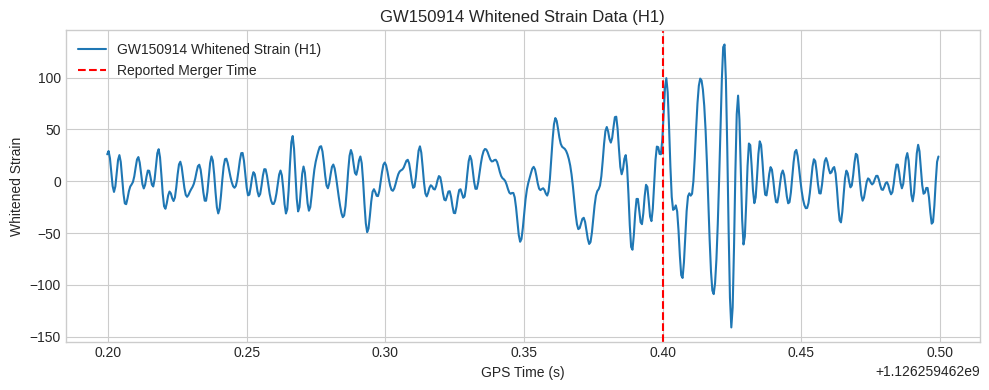

First few t_fit (time to merger, should decrease): [0.19480434 0.1877312  0.1844034  0.18059449 0.17276999 0.16606822
 0.16152852 0.15545963 0.15022831 0.14663889]
First few f83_fit (f^-8/3, should decrease): [3.29067589e-07 3.29067589e-07 3.53836545e-07 1.59650926e-06
 5.65032931e-07 1.22543577e-06 1.22543577e-06 8.24701543e-07
 5.65032931e-07 8.24701543e-07]
Slope from linregress (f^-8/3 vs time_to_merger): -3.940e-05
Estimated chirp mass: 6.98 M_sun (GW150914 expected: ~28-31 M_sun)


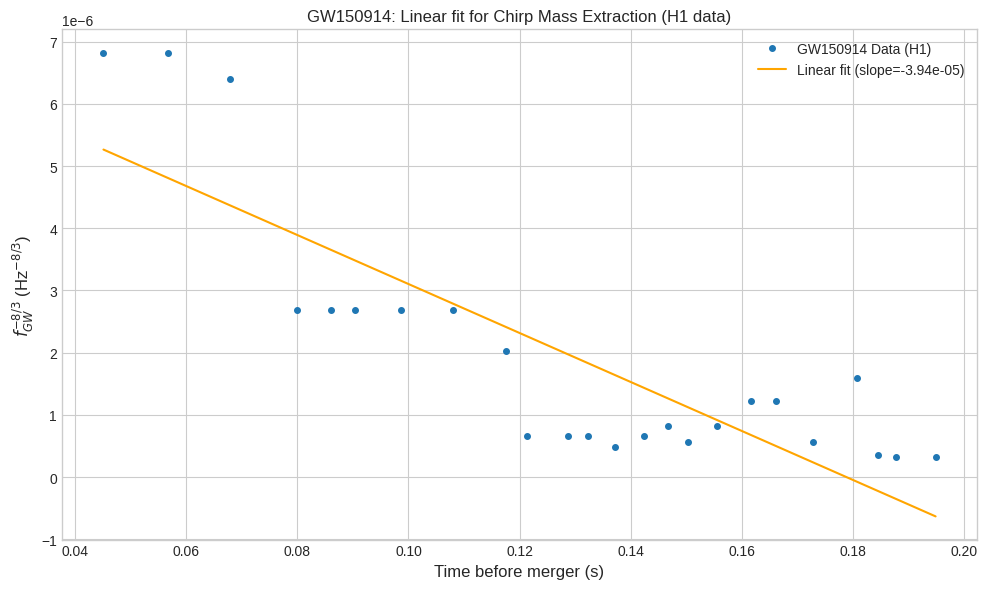

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc.catalog import Merger
from pycbc.filter import resample_to_delta_t, highpass
from pycbc.psd import interpolate, inverse_spectrum_truncation
from scipy.stats import linregress
from scipy.constants import G, c, pi
from scipy.ndimage import median_filter

# Constants
M_SOLAR = 1.98847e30

# 1. Data loading and conditioning for GW150914
merger = Merger("GW150914")
event_time = merger.time  # GPS time of the merger

# Get strain data from H1 detector
strain = merger.strain('H1')
strain = highpass(strain, 15.0) # Initial highpass
strain = resample_to_delta_t(strain, 1.0/2048) # Resample

# Condition the data: crop, PSD, whiten
conditioned = strain.crop(2, 2) # Crop 2s from start and end
psd = conditioned.psd(4)        # PSD estimate using 4s segments
psd = interpolate(psd, conditioned.delta_f)
psd = inverse_spectrum_truncation(psd, int(4 * conditioned.sample_rate), low_frequency_cutoff=15.0)

white_strain = (conditioned.to_frequencyseries() / psd**0.5).to_timeseries()
# Further bandpassing on whitened data
white_strain = white_strain.highpass_fir(30., 512).lowpass_fir(300, 512)
white_strain = white_strain.time_slice(merger.time-.2, merger.time+.1)

# Define t_shifted (time relative to merger) and h (strain data) for subsequent analysis
t_shifted = white_strain.sample_times.numpy() - event_time
h = white_strain.numpy()

# 2. Plot the whitened waveform for comparison
plt.figure(figsize=(10,4))
# Plotting with absolute GPS time for this overview
plt.plot(white_strain.sample_times, h, label="GW150914 Whitened Strain (H1)")
plt.axvline(event_time, color='r', linestyle='--', label='Reported Merger Time')
plt.xlabel("GPS Time (s)")
plt.ylabel("Whitened Strain")
plt.title("GW150914 Whitened Strain Data (H1)")
plt.legend()
plt.tight_layout()
plt.show()

# 3. Select inspiral segment before merger (e.g., -0.4s to -0.03s relative to merger)
# t_shifted is already time relative to merger
start_time_relative = -0.4
end_time_relative = -0.03
selection_mask = (t_shifted > start_time_relative) & (t_shifted < end_time_relative)
h_insp = h[selection_mask]
t_insp = t_shifted[selection_mask] # t_insp is also time relative to merger

# 4. Zero-crossings: find times where strain crosses zero with sign change
zero_crossings = []
for i in range(len(h_insp)-1):
    if h_insp[i] * h_insp[i+1] < 0:
        # Linear interpolation for more accurate crossing
        t_zero = t_insp[i] - h_insp[i] * (t_insp[i+1] - t_insp[i]) / (h_insp[i+1] - h_insp[i])
        zero_crossings.append(t_zero)
zero_crossings = np.array(zero_crossings)

# Ensure we have an even number of zero crossings for full GW cycles
if len(zero_crossings) % 2 != 0:
    zero_crossings = zero_crossings[:-1]

# 5. Calculate period and GW frequency using every **other** zero crossing (full GW cycle)
if len(zero_crossings) > 1:
    zero_crossings = np.sort(zero_crossings)  # earliest to latest (most negative to least negative)
    period_times = zero_crossings[::2]
    Pgw = np.diff(period_times)
    t_period = period_times[1:]         # time for each full period (negative, increasing towards zero)
    f_gw = 1.0 / Pgw
else:
    print("Not enough zero crossings found in the selected segment to calculate periods.")
    f_gw = np.array([]) # Ensure f_gw is defined

if len(f_gw) > 0:
    # 6. Use time before merger (positive, decreasing towards zero if t_period was sorted correctly)
    t_before_merger = -t_period  # t_period is negative, so t_before_merger is positive

    # 7. Remove outliers using median filter
    f_gw_medfilt = median_filter(f_gw, size=5) # Apply filter only if f_gw has enough points
    f83 = f_gw_medfilt ** (-8/3)

    # 8. Only use the positive, pre-merger frequencies from valid calculations
    valid_mask = (t_before_merger > 0) & (f_gw_medfilt > 0) & (~np.isnan(f83)) & (~np.isinf(f83))
    t_fit_raw = t_before_merger[valid_mask]
    f83_fit_raw = f83[valid_mask]

    if len(t_fit_raw) > 3: # Need at least a few points for a meaningful fit
        # 9. Sort for decreasing t_fit (time_to_merger, approaching merger)
        sort_idx = np.argsort(-t_fit_raw)  # sorts t_fit_raw into strictly descending order
        t_fit = t_fit_raw[sort_idx]
        f83_fit = f83_fit_raw[sort_idx]

        # 10. Linear fit to f^{-8/3} vs time_before_merger
        slope_from_linregress, intercept, r, p, err = linregress(t_fit, f83_fit)

        print("First few t_fit (time to merger, should decrease):", t_fit[:10])
        print("First few f83_fit (f^-8/3, should decrease):", f83_fit[:10])
        print(f"Slope from linregress (f^-8/3 vs time_to_merger): {slope_from_linregress:.3e}")

        # 11. Chirp mass extraction
        if slope_from_linregress < 0: # C1 in f^-8/3 = C0 + C1*tau (where tau is time from merger, or -t_before_merger)
                                      # Or f^-8/3 = C0 - C1*t_before_merger.
                                      # If t_fit is decreasing (time_to_merger), and f83_fit is decreasing, slope is positive.
            mc_kg = c**3 / (G * (8 * pi)**(8/5)) * (5 * (-slope_from_linregress))**(3/5)
            mc_solar = mc_kg / M_SOLAR
            print(f"Estimated chirp mass: {mc_solar:.2f} M_sun (GW150914 expected: ~28-31 M_sun)")
        else:
            print("Slope from linregress is not negative. Check data, fit, or inspiral segment selection.")

        # 12. Plotting the fit
        plt.figure(figsize=(10,6))
        plt.plot(t_fit, f83_fit, 'o', markersize=4, label='GW150914 Data (H1)')
        plt.plot(t_fit, slope_from_linregress*t_fit + intercept, '-', color='orange', label=f'Linear fit (slope={slope_from_linregress:.2e})')
        plt.xlabel('Time before merger (s)', fontsize=12)
        plt.ylabel(r'$f_{GW}^{-8/3}$ (Hz$^{-8/3}$)', fontsize=12)
        plt.title(f'GW150914: Linear fit for Chirp Mass Extraction (H1 data)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough valid data points for a linear fit after filtering.")
else:
    print("No valid GW frequencies calculated to proceed with the fit.")


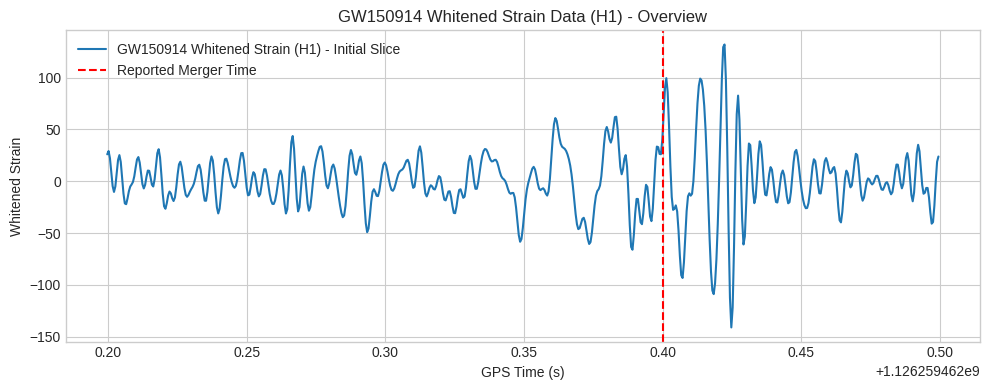

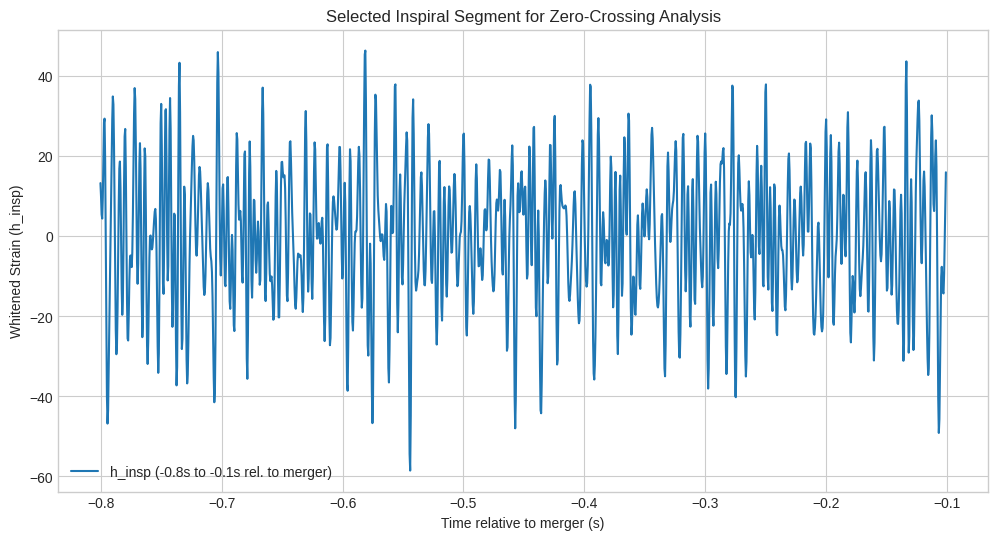

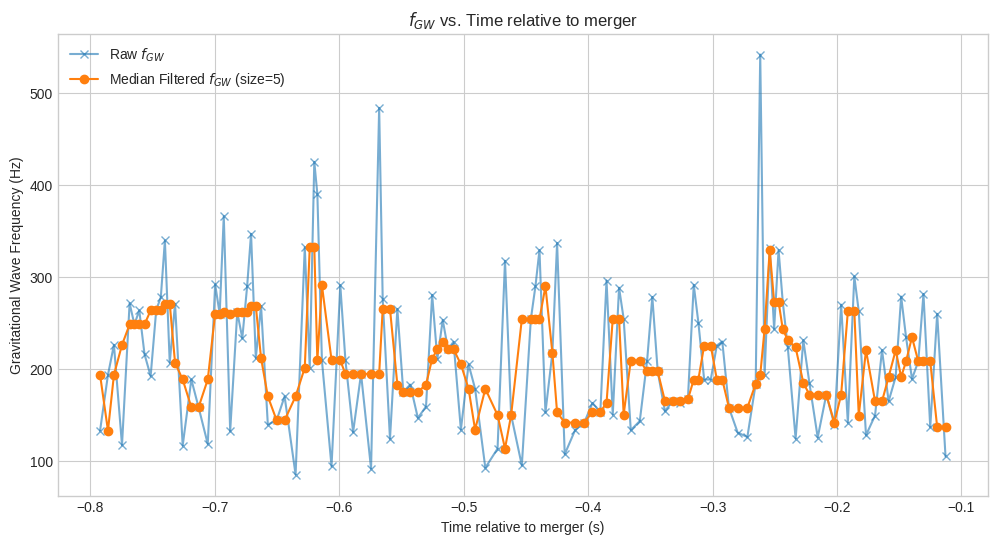


--- Fit Results ---
Selected inspiral segment: -0.8s to -0.1s relative to merger.
Median filter size for f_gw: 5
Number of points for fit: 125
First few t_fit (time to merger, should decrease): [0.79224945 0.78589812 0.7811018  0.77461977 0.76850692 0.76465025
 0.76073909 0.75652649 0.75160795 0.7471104 ]
First few f83_fit (f^-8/3, should decrease): [7.98549486e-07 2.18153943e-06 7.98549486e-07 5.27490393e-07
 4.10609712e-07 4.10609712e-07 4.10609712e-07 4.10609712e-07
 3.50355261e-07 3.48777989e-07]
Slope from linregress (f^-8/3 vs time_to_merger): -4.978e-07
R-squared value: 0.037
Slope from linregress is -4.978e-07, which is not sufficiently positive as expected.
This indicates issues with the data points not following the theoretical trend.
Cannot reliably estimate chirp mass. Review plots, inspiral segment, and filtering.


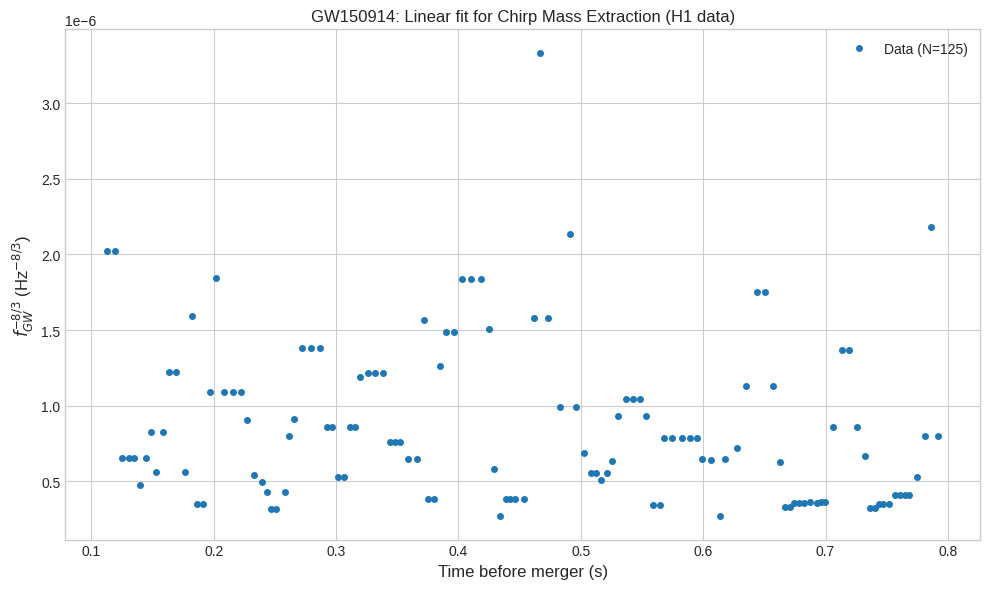

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc.catalog import Merger
from pycbc.filter import resample_to_delta_t, highpass
from pycbc.psd import interpolate, inverse_spectrum_truncation
from scipy.stats import linregress
from scipy.constants import G, c, pi
from scipy.ndimage import median_filter

# Constants
M_SOLAR = 1.98847e30

# 1. Data loading and conditioning for GW150914
merger = Merger("GW150914")
event_time = merger.time  # GPS time of the merger

# Get strain data from H1 detector
strain_data = merger.strain('H1') # Renamed to avoid conflict later
strain_data = highpass(strain_data, 15.0) # Initial highpass
strain_data = resample_to_delta_t(strain_data, 1.0/2048) # Resample

# Condition the data: crop, PSD, whiten (for initial overview plot)
conditioned_overview = strain_data.crop(2, 2)
psd_overview = conditioned_overview.psd(4)
psd_overview = interpolate(psd_overview, conditioned_overview.delta_f)
psd_overview = inverse_spectrum_truncation(psd_overview, int(4 * conditioned_overview.sample_rate), low_frequency_cutoff=15.0)
white_strain_overview = (conditioned_overview.to_frequencyseries() / psd_overview**0.5).to_timeseries()
white_strain_overview = white_strain_overview.highpass_fir(30., 512).lowpass_fir(300, 512)
white_strain_overview = white_strain_overview.time_slice(merger.time-.2, merger.time+.1)

# Prepare strain data for detailed analysis (potentially wider window)
analysis_strain = strain_data.crop(2,2) # Re-crop for a potentially wider analysis window
analysis_psd = analysis_strain.psd(4)
analysis_psd = interpolate(analysis_psd, analysis_strain.delta_f)
analysis_psd = inverse_spectrum_truncation(analysis_psd, int(4 * analysis_strain.sample_rate), low_frequency_cutoff=15.0)
analysis_white_strain = (analysis_strain.to_frequencyseries() / analysis_psd**0.5).to_timeseries()
analysis_white_strain = analysis_white_strain.highpass_fir(30., 512).lowpass_fir(300, 512)

# --- USER ADJUSTABLE PARAMETERS ---
# Select inspiral segment before merger (e.g., -0.8s to -0.1s relative to merger)
# This segment is critical, adjust as needed for cleaner f_gw
start_time_relative = -0.8  # Start of the segment relative to merger time
end_time_relative = -0.1   # End of the segment relative to merger time
median_filter_size = 5      # Odd number, try 5, 7, or 9
# --- END USER ADJUSTABLE PARAMETERS ---

inspiral_start_gps = merger.time + start_time_relative
inspiral_end_gps = merger.time + end_time_relative

if inspiral_start_gps < analysis_white_strain.start_time or inspiral_end_gps > analysis_white_strain.end_time:
    print(f"Warning: Requested inspiral slice ({inspiral_start_gps:.2f} to {inspiral_end_gps:.2f}) "
          f"might be outside available data range ({analysis_white_strain.start_time:.2f} to {analysis_white_strain.end_time:.2f}).")
    actual_start_gps = max(inspiral_start_gps, analysis_white_strain.start_time)
    actual_end_gps = min(inspiral_end_gps, analysis_white_strain.end_time)
    print(f"Using actual slice: {actual_start_gps:.2f} to {actual_end_gps:.2f}")
    analysis_white_strain_inspiral = analysis_white_strain.time_slice(actual_start_gps, actual_end_gps)
else:
    analysis_white_strain_inspiral = analysis_white_strain.time_slice(inspiral_start_gps, inspiral_end_gps)

t_shifted_inspiral = analysis_white_strain_inspiral.sample_times.numpy() - event_time
h_insp = analysis_white_strain_inspiral.numpy()

# 2. Plot the initially processed whitened waveform for overview
plt.figure(figsize=(10,4))
plt.plot(white_strain_overview.sample_times, white_strain_overview.numpy(), label="GW150914 Whitened Strain (H1) - Initial Slice")
plt.axvline(event_time, color='r', linestyle='--', label='Reported Merger Time')
plt.xlabel("GPS Time (s)")
plt.ylabel("Whitened Strain")
plt.title("GW150914 Whitened Strain Data (H1) - Overview")
plt.legend()
plt.tight_layout()
plt.show()

# --- DIAGNOSTIC PLOT 1: Inspiral Segment for Zero-Crossings ---
plt.figure(figsize=(12, 6))
plt.plot(t_shifted_inspiral, h_insp, label=f'h_insp ({start_time_relative}s to {end_time_relative}s rel. to merger)')
plt.xlabel("Time relative to merger (s)")
plt.ylabel("Whitened Strain (h_insp)")
plt.title("Selected Inspiral Segment for Zero-Crossing Analysis")
plt.legend()
plt.grid(True)
plt.show()
# --- END DIAGNOSTIC PLOT 1 ---

# 4. Zero-crossings
if len(h_insp) < 2:
    print("Not enough data points in the selected inspiral segment for zero-crossing analysis.")
    f_gw_raw = np.array([]) # Initialize f_gw_raw
else:
    zero_crossings = []
    for i in range(len(h_insp)-1):
        if h_insp[i] * h_insp[i+1] < 0:
            t_zero = t_shifted_inspiral[i] - h_insp[i] * (t_shifted_inspiral[i+1] - t_shifted_inspiral[i]) / (h_insp[i+1] - h_insp[i])
            zero_crossings.append(t_zero)
    zero_crossings = np.array(zero_crossings)

    if len(zero_crossings) % 2 != 0:
        zero_crossings = zero_crossings[:-1]

    if len(zero_crossings) > 3:
        zero_crossings = np.sort(zero_crossings)
        period_defining_times = zero_crossings[::2]
        Pgw = np.diff(period_defining_times)
        t_gw_midpoint_relative = (period_defining_times[:-1] + period_defining_times[1:]) / 2.0

        valid_Pgw_mask = Pgw > 1e-4 # Avoid extremely small/zero periods from noisy crossings
        Pgw = Pgw[valid_Pgw_mask]
        t_gw_midpoint_relative = t_gw_midpoint_relative[valid_Pgw_mask]

        if len(Pgw) > 0:
            f_gw_raw = 1.0 / Pgw
        else:
            print("No valid periods found after filtering out small/zero Pgw.")
            f_gw_raw = np.array([])
    else:
        print("Not enough zero crossings found in the selected segment to calculate periods.")
        f_gw_raw = np.array([])

if len(f_gw_raw) > 0:
    # 7. Remove outliers using median filter
    if len(f_gw_raw) >= median_filter_size:
        f_gw_medfilt = median_filter(f_gw_raw, size=median_filter_size)
    else:
        print(f"Not enough f_gw points ({len(f_gw_raw)}) for median filter of size {median_filter_size}. Using unfiltered f_gw.")
        f_gw_medfilt = f_gw_raw # Assign f_gw_raw to f_gw_medfilt if not filtered

    # --- DIAGNOSTIC PLOT 2: Calculated f_GW ---
    plt.figure(figsize=(12, 6))
    plt.plot(t_gw_midpoint_relative, f_gw_raw, 'x-', label='Raw $f_{{GW}}$', alpha=0.6) # Corrected f-string
    if 'f_gw_medfilt' in locals() and len(f_gw_medfilt) == len(t_gw_midpoint_relative): # Check if f_gw_medfilt exists and has same length
         plt.plot(t_gw_midpoint_relative, f_gw_medfilt, 'o-', label=f'Median Filtered $f_{{GW}}$ (size={median_filter_size})') # Corrected f-string
    plt.xlabel("Time relative to merger (s)")
    plt.ylabel("Gravitational Wave Frequency (Hz)")
    plt.title("$f_{{GW}}$ vs. Time relative to merger") # Corrected f-string (though not an f-string here, good practice)
    plt.legend()
    plt.grid(True)
    plt.show()
    # --- END DIAGNOSTIC PLOT 2 ---

    f83 = f_gw_medfilt ** (-8/3)
    t_before_merger = -t_gw_midpoint_relative

    valid_mask = (t_before_merger > 0) & (f_gw_medfilt > 20) & (f_gw_medfilt < 300) & (~np.isnan(f83)) & (~np.isinf(f83))
    t_fit_raw = t_before_merger[valid_mask]
    f83_fit_raw = f83[valid_mask]

    if len(t_fit_raw) > 3:
        sort_idx = np.argsort(t_fit_raw)[::-1]
        t_fit = t_fit_raw[sort_idx]
        f83_fit = f83_fit_raw[sort_idx]

        slope_from_linregress, intercept, r, p, err = linregress(t_fit, f83_fit)

        print(f"\n--- Fit Results ---")
        print(f"Selected inspiral segment: {start_time_relative}s to {end_time_relative}s relative to merger.")
        print(f"Median filter size for f_gw: {median_filter_size}")
        print(f"Number of points for fit: {len(t_fit)}")
        if len(t_fit) > 0:
             print("First few t_fit (time to merger, should decrease):", t_fit[:min(10, len(t_fit))])
             print("First few f83_fit (f^-8/3, should decrease):", f83_fit[:min(10, len(f83_fit))])
        print(f"Slope from linregress (f^-8/3 vs time_to_merger): {slope_from_linregress:.3e}")
        print(f"R-squared value: {r**2:.3f}")

        if slope_from_linregress > 1e-10:
            mc_kg = (c**3 / (G * (8 * pi)**(8.0/5.0))) * (5.0 * slope_from_linregress)**(3.0/5.0)
            mc_solar = mc_kg / M_SOLAR
            print(f"Estimated chirp mass: {mc_solar:.2f} M_sun (GW150914 expected: ~28-31 M_sun)")
            if not (20 < mc_solar < 40):
                 print("Warning: Estimated chirp mass is significantly different from the expected value.")
        else:
            print(f"Slope from linregress is {slope_from_linregress:.3e}, which is not sufficiently positive as expected.")
            print("This indicates issues with the data points not following the theoretical trend.")
            print("Cannot reliably estimate chirp mass. Review plots, inspiral segment, and filtering.")

        plt.figure(figsize=(10,6))
        plt.plot(t_fit, f83_fit, 'o', markersize=4, label=f'Data (N={len(t_fit)})')
        if slope_from_linregress > 1e-10:
            plt.plot(t_fit, slope_from_linregress*t_fit + intercept, '-', color='orange',
                     label=f'Linear fit (slope={slope_from_linregress:.2e}, $R^2$={r**2:.2f})')
        plt.xlabel('Time before merger (s)', fontsize=12)
        plt.ylabel(r'$f_{GW}^{-8/3}$ (Hz$^{-8/3}$)', fontsize=12) # Here $f_{GW}$ is okay as it's a raw string part
        plt.title(f'GW150914: Linear fit for Chirp Mass Extraction (H1 data)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough valid data points for a linear fit after filtering and sorting.")
else:
    print("No valid GW frequencies (f_gw_raw) calculated to proceed with the fit.")

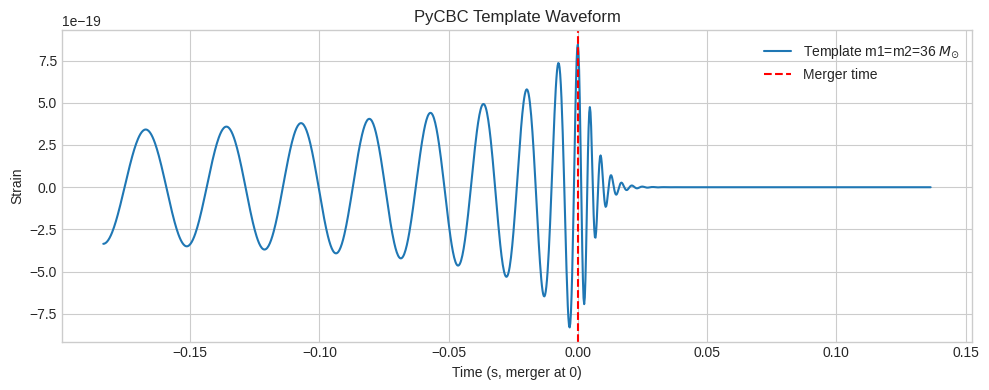

First few t_fit (time to merger, should decrease): [0.14360093 0.11412486 0.08708522 0.06270881 0.04138411]
First few f83_fit (f^-8/3, should decrease): [8.29059653e-05 8.29059653e-05 6.58671795e-05 4.99558056e-05
 4.99558056e-05]
Slope from linregress (f^-8/3 vs time_to_merger): 3.854e-04
Estimated chirp mass: 27.42 M_sun (should be ~31 M_sun for m1=m2=36)
Theoretical chirp mass (m1=m2=36): 31.34 M_sun


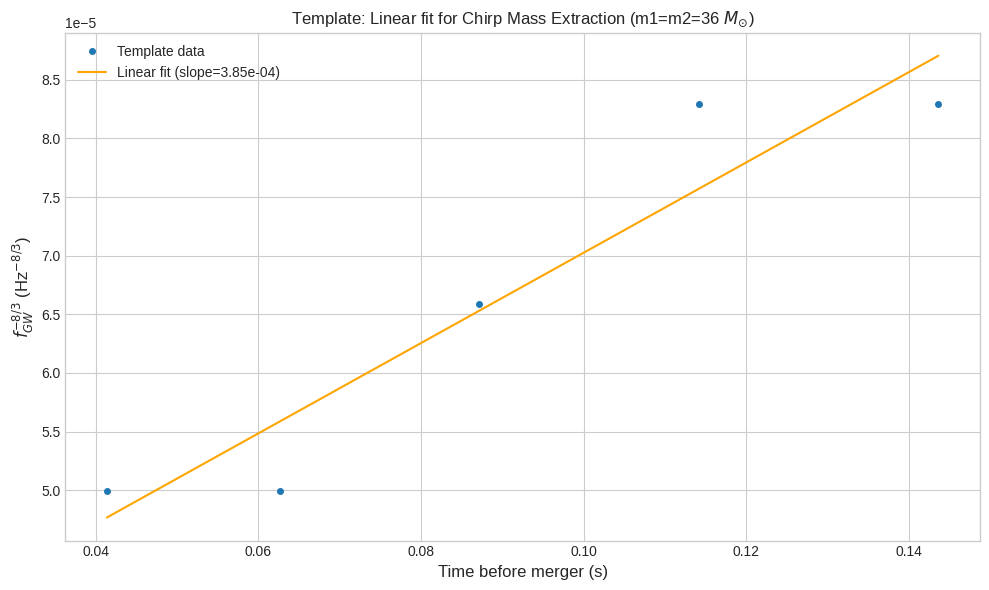

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc.waveform import get_td_waveform
from scipy.stats import linregress
from scipy.constants import G, c, pi

# Constants
M_SOLAR = 1.98847e30

# 1. Generate synthetic template waveform (merger at t=0)
m1, m2 = 36, 36
hp, _ = get_td_waveform(approximant="SEOBNRv4", mass1=m1, mass2=m2, delta_t=1.0/4096, f_lower=30)
t = hp.sample_times
h = hp.numpy()
t0 = t[np.argmax(np.abs(h))]
t_shifted = t - t0  # merger at t=0

# 2. Plot the template waveform for comparison
plt.figure(figsize=(10,4))
plt.plot(t_shifted, h, label=f"Template m1=m2={m1} $M_{{\\odot}}$")
plt.axvline(0, color='r', linestyle='--', label='Merger time')
plt.xlabel("Time (s, merger at 0)")
plt.ylabel("Strain")
plt.title("PyCBC Template Waveform")
plt.legend()
plt.tight_layout()
plt.show()

# 3. Select inspiral segment before merger (like GW150914 -0.4s to -0.03s)
start_time = -0.4
end_time = -0.03
mask = (t_shifted > start_time) & (t_shifted < end_time)
h_insp = h[mask]
t_insp = t_shifted[mask]

# 4. Zero-crossings: find times where strain crosses zero with sign change
zero_crossings = []
for i in range(len(h_insp)-1):
    if h_insp[i] * h_insp[i+1] < 0:
        # Linear interpolation for more accurate crossing
        t_zero = t_insp[i] - h_insp[i] * (t_insp[i+1] - t_insp[i]) / (h_insp[i+1] - h_insp[i])
        zero_crossings.append(t_zero)
zero_crossings = np.array(zero_crossings)

# Ensure we have an even number of zero crossings for full GW cycles
if len(zero_crossings) % 2 != 0:
    zero_crossings = zero_crossings[:-1]

# 5. Calculate period and GW frequency using every **other** zero crossing (full GW cycle)
zero_crossings = np.sort(zero_crossings)  # earliest to latest
period_times = zero_crossings[::2]
Pgw = np.diff(period_times)
t_period = period_times[1:]         # time for each full period (negative, increasing towards zero)
f_gw = 1.0 / Pgw

# 6. Use time before merger (positive, decreasing towards zero)
t_before_merger = -t_period  # t=0 is merger. This will be positive and decreasing.

# 7. Remove outliers (optional, improves fit robustness)
from scipy.ndimage import median_filter
f_gw_medfilt = median_filter(f_gw, size=5)
f83 = f_gw_medfilt ** (-8/3) # As f_gw_medfilt increases (closer to merger), f83 decreases.

# 8. Only use the positive, pre-merger frequencies
mask = (t_before_merger > 0) & (f_gw_medfilt > 0)
t_fit_raw = t_before_merger[mask] # t_fit_raw is already decreasing
f83_fit_raw = f83[mask]         # f83_fit_raw is correspondingly decreasing

# 9. Sort for decreasing t_fit (toward merger) - this step is redundant if t_before_merger is already decreasing
# but ensures order if t_before_merger wasn't perfectly monotonic decreasing due to filtering/masking.
sort_idx = np.argsort(-t_fit_raw)  # sorts t_fit_raw into strictly descending order
t_fit = t_fit_raw[sort_idx]
f83_fit = f83_fit_raw[sort_idx]

# 10. Linear fit to f^{-8/3} vs time_before_merger
# t_fit is decreasing, f83_fit is decreasing. Slope from linregress will be POSITIVE.
slope_from_linregress, intercept, r, p, err = linregress(t_fit, f83_fit)

print("First few t_fit (time to merger, should decrease):", t_fit[:10])
print("First few f83_fit (f^-8/3, should decrease):", f83_fit[:10])
print(f"Slope from linregress (f^-8/3 vs time_to_merger): {slope_from_linregress:.3e}")

# 11. Chirp mass extraction
# The slope 'S' in the chirp mass formula is d(f^-8/3)/d(tau), which is -C1.
# Our slope_from_linregress is C1. So S_formula = -slope_from_linregress.
# The term in the chirp mass formula is (-5 * S_formula)^(3/5)
# which becomes (-5 * (-slope_from_linregress))^(3/5) = (5 * slope_from_linregress)^(3/5)

if slope_from_linregress > 0: # This checks if the physical relationship holds (positive C1)
    mc_kg = c**3 / (G * (8 * pi)**(8/5)) * (5 * slope_from_linregress)**(3/5)
    mc_solar = mc_kg / M_SOLAR
    print(f"Estimated chirp mass: {mc_solar:.2f} M_sun (should be ~31 M_sun for m1=m2=36)")
    mc_theory = (m1*m2)**(3/5) / (m1 + m2)**(1/5)
    print(f"Theoretical chirp mass (m1=m2={m1}): {mc_theory:.2f} M_sun")
else:
    print("Slope from linregress is not positive. Check data, fit, or inspiral segment selection.")

# 12. Plotting the fit
# Matplotlib will plot t_fit on x-axis from min to max (so, increasing time to merger).
# The corresponding f83_fit values will also be increasing. Plot shows positive slope.
plt.figure(figsize=(10,6))
plt.plot(t_fit, f83_fit, 'o', markersize=4, label='Template data')
plt.plot(t_fit, slope_from_linregress*t_fit + intercept, '-', color='orange', label=f'Linear fit (slope={slope_from_linregress:.2e})')
plt.xlabel('Time before merger (s)', fontsize=12)
plt.ylabel(r'$f_{GW}^{-8/3}$ (Hz$^{-8/3}$)', fontsize=12)
plt.title(f'Template: Linear fit for Chirp Mass Extraction (m1=m2={m1} $M_{{\\odot}}$)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()